## Importing libraries

In [56]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Wineqt dataset


In [57]:
data_path = 'wineqt.csv'
data1 = pd.read_csv(data_path)
data1.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## EDA


In [58]:
missing_values = data1.isnull().sum()
missing_values

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [59]:
duplicate_rows = data1.duplicated().sum()
duplicate_rows

0

In [60]:
data =data1.drop('Id', axis = 1)
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Calculate basic statistics such as mean, median, and standard deviation for numerical columns.

In [61]:
numerical_stats = data.describe()
numerical_stats

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


Generate summary statistics for categorical columns, including frequency counts and percentage distribution.


In [62]:
quality_counts = data['quality'].value_counts()
quality_percentage = data['quality'].value_counts(normalize=True) * 100
quality_percentage

quality
5    42.257218
6    40.419948
7    12.510936
4     2.887139
8     1.399825
3     0.524934
Name: proportion, dtype: float64

Explore the relationships between variables using appropriate EDA techniques such as correlation analysis or cross-tabulation.

In [63]:
features = [col for col in data.columns if col != 'quality']
features

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [64]:
dummy_df = pd.get_dummies(data, columns = ['quality'])
dummy_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_3,quality_4,quality_5,quality_6,quality_7,quality_8
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,False,False,True,False,False,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,False,False,True,False,False,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,False,False,True,False,False,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,False,False,False,True,False,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,False,False,True,False,False,False


The plot below shows the correlation between different features and the correlation between each features to their quality

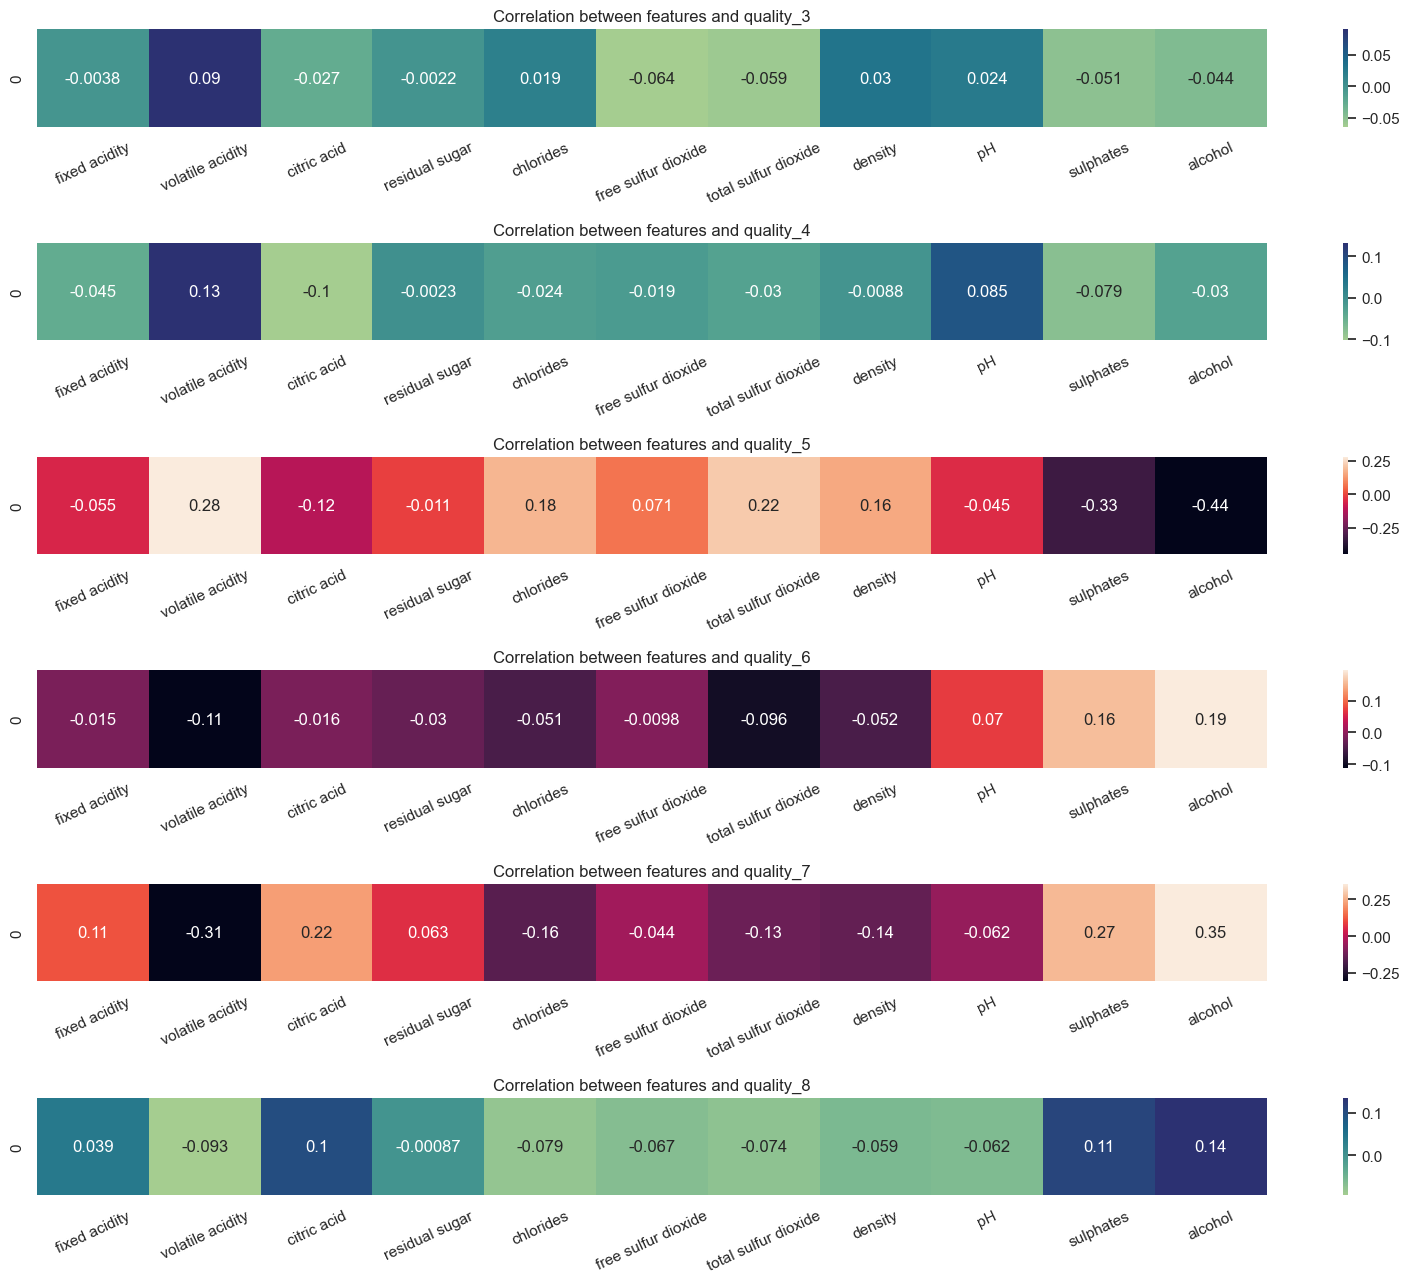

In [65]:
fig, axes = plt.subplots(6, 1, figsize = (16, 13))
r = 0
features = [col for col in data.columns if col != 'quality']

for quality in ['quality_3', 'quality_4', 'quality_5', 'quality_6', 'quality_7', 'quality_8']:
    corr = pd.DataFrame(dummy_df[features].corrwith(dummy_df[quality], method='spearman'))

    if r > 1 and r < 5:
      sns.heatmap(corr.T, annot = True, ax = axes[r])
    else:
      sns.heatmap(corr.T, annot = True, cmap = 'crest', ax = axes[r])

    labels = axes[r].xaxis.get_ticklabels()
    for label in labels:
      label.set_rotation(25)

    axes[r].set_title(f'Correlation between features and {quality}')
    r += 1

plt.tight_layout()
plt.show()

let's take a look at the distribution of different features

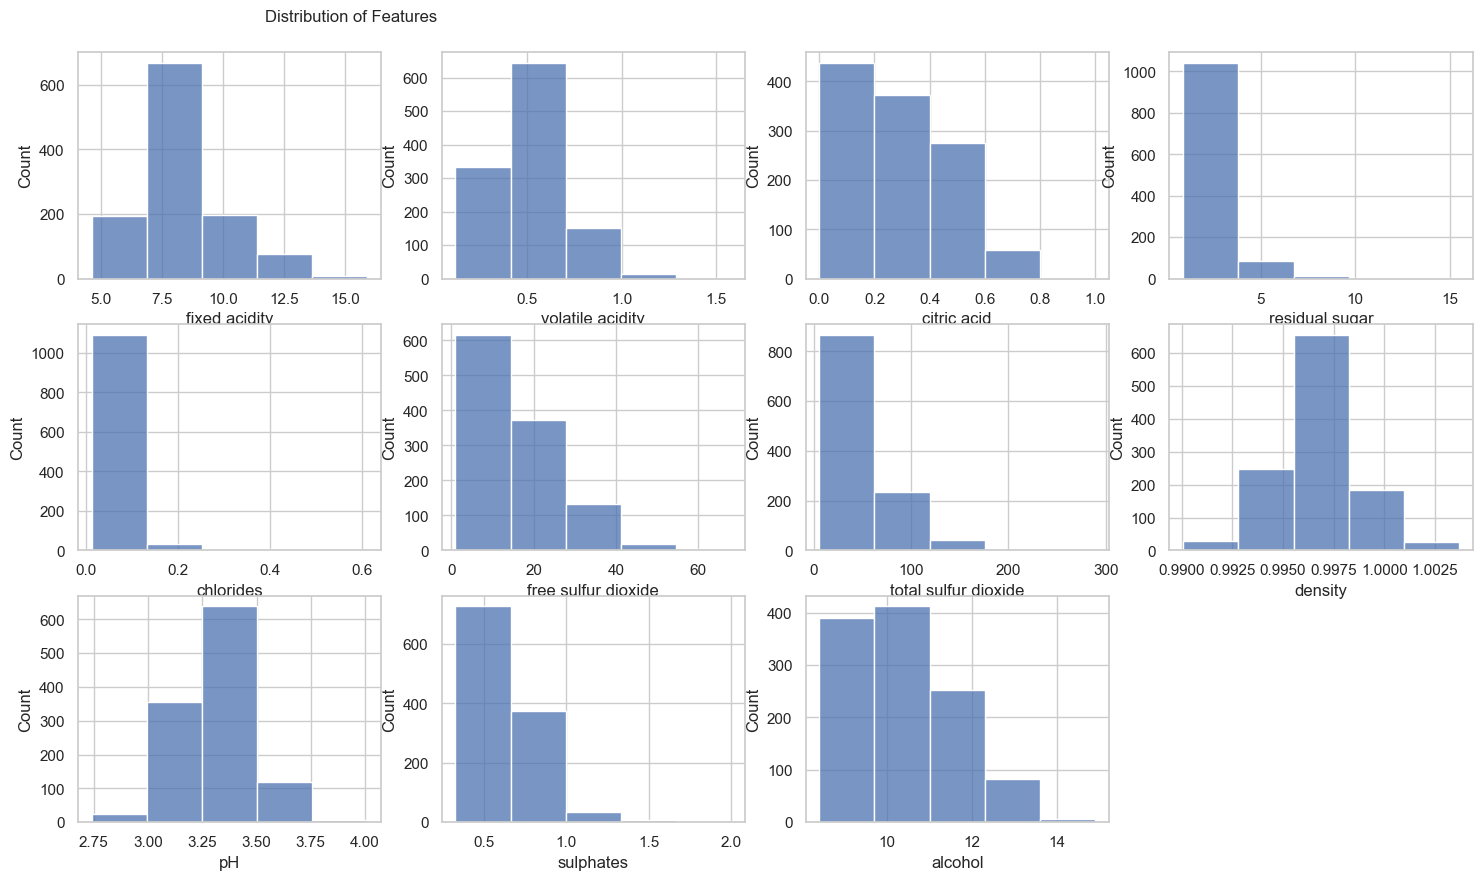

In [66]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
r, c = 0, 0

for i, column in enumerate(features):
  r = i //4
  c = i % 4
  sns.histplot(data[column], bins = 5, ax = axes[r, c])
  axes[r, c].grid(True)

fig.delaxes(axes[2, 3])

plt.title('Distribution of Features', y = 3.5, x = -1.5)
plt.show()

let's take a closer look at how the features affects the quality of the wine

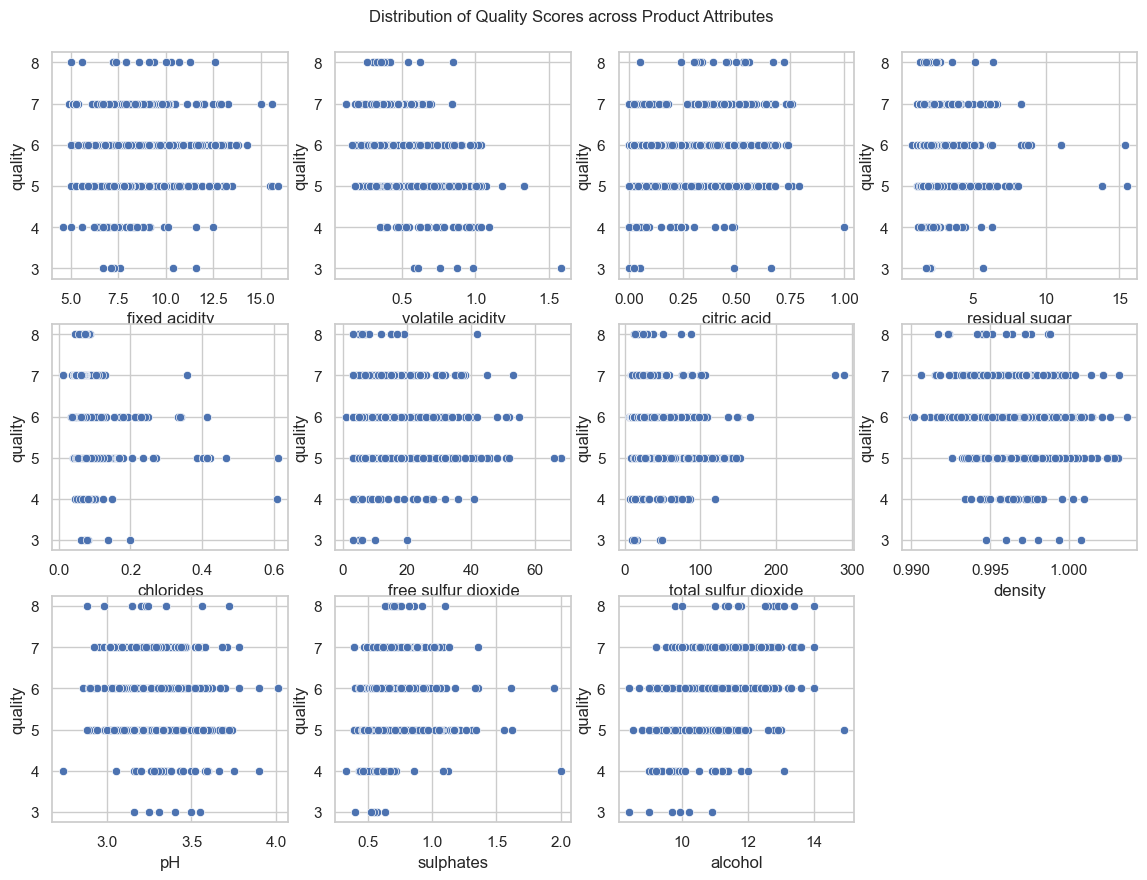

In [67]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
r, c = 0, 0


for i, column in enumerate(features):
  r = i //4
  c = i % 4
  sns.scatterplot(data = data, x = column, y = 'quality', ax = axes[r, c])

fig.delaxes(axes[2, 3])

plt.title('Distribution of Quality Scores across Product Attributes', y = 3.5, x = -0.2)
plt.show()

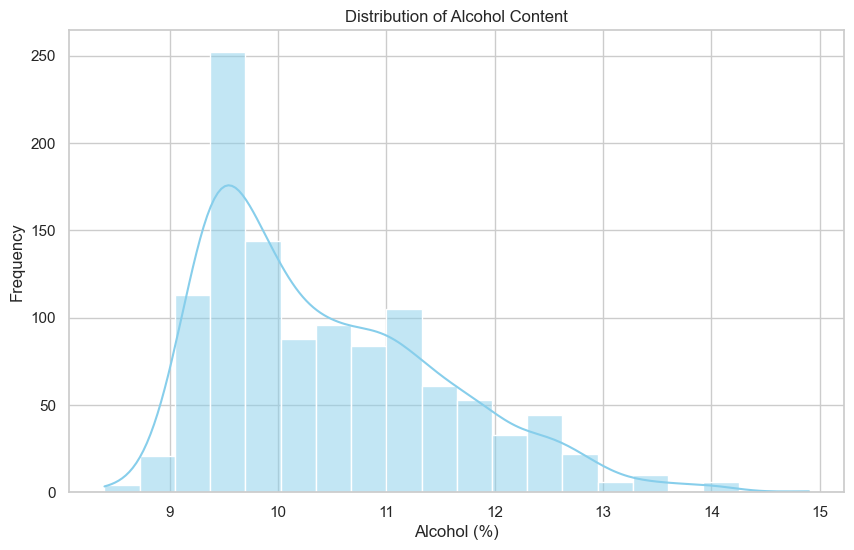

In [68]:
sns.set(style="whitegrid")

# Histogram for Alcohol Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['alcohol'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Alcohol Content')
plt.xlabel('Alcohol (%)')
plt.ylabel('Frequency')
plt.show()

C:\Users\HON\AppData\Local\Temp\ipykernel_4780\2935767930.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=data, palette='coolwarm')


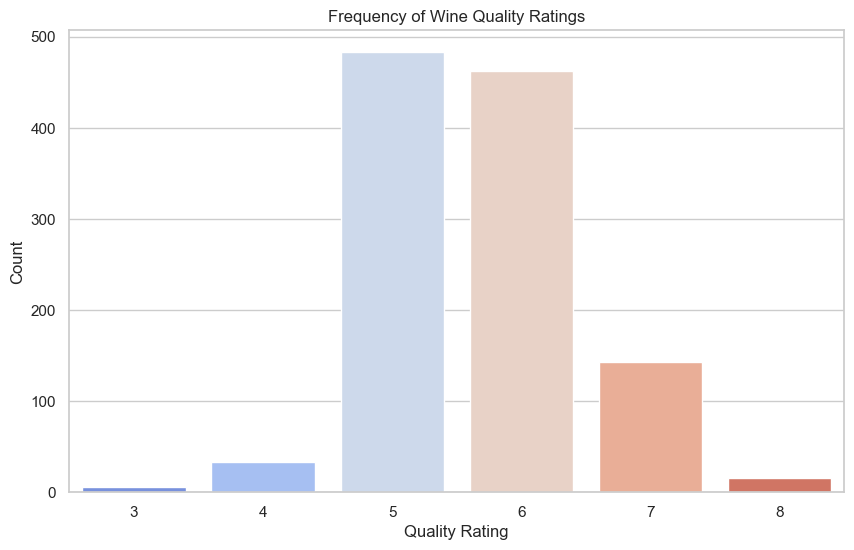

In [69]:
# Bar Plot for Quality Frequency
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=data, palette='coolwarm')
plt.title('Frequency of Wine Quality Ratings')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.show()

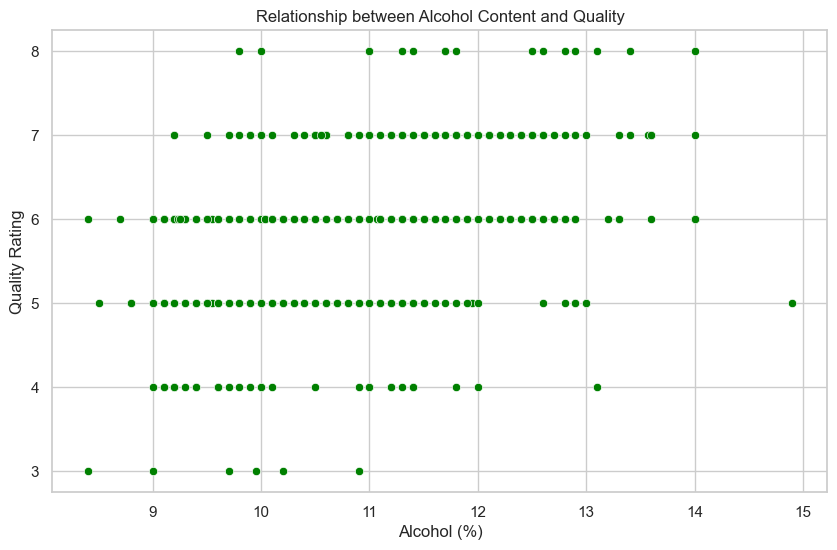

In [71]:
# Scatter Plot for Alcohol vs Quality
plt.figure(figsize=(10, 6))
sns.scatterplot(x='alcohol', y='quality', data=data, color='green')
plt.title('Relationship between Alcohol Content and Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality Rating')
plt.show()

# Data Wrangling
No Missing Values or Duplicates: The dataset was clean with no missing values or duplicate rows, which is ideal for a straightforward analysis.

Dataset Composition: After cleaning, the dataset contained 1,143 entries and 13 columns, indicating a substantial amount of data to analyze wine quality based on physicochemical properties.

# Exploratory Data Analysis (EDA)
Variable Scales and Distributions: The basic statistics revealed that the dataset's variables had different scales and distributions. This variability is essential for understanding the range and general behavior of each feature.

Wine Quality Distribution: The majority of wines were rated as medium quality (5 and 6), with fewer instances of high (7 and 8) and low (3 and 4) quality wines.
Correlation Analysis

Alcohol and Quality: There was a notable positive correlation between alcohol content and wine quality, suggesting that wines with higher alcohol percentages tend to have higher quality ratings.
Volatile Acidity and Quality: A negative correlation was observed between volatile acidity and wine quality, indicating that lower levels of volatile acidity are associated with higher quality wines.

# Data Visualizations
## Correlation Heatmap:

Alcohol and Quality: There is a strong positive correlation (0.48) between alcohol content and quality, suggesting that wines with higher alcohol content tend to have higher quality ratings.

Volatile Acidity and Quality: A notable negative correlation (-0.41) exists between volatile acidity and quality, indicating that wines with lower volatile acidity are often of higher quality.

Citric Acid and Fixed Acidity: Both these acids show a strong positive correlation with each other (0.67), which is expected as citric acid is a component of the total fixed acidity.

## Distribution of Features:

The histograms show the distributions of different physicochemical properties of the wines. Most variables appear right-skewed (e.g., chlorides, sulphates, residual sugar, and free sulfur dioxide), indicating a concentration of lower values with fewer high-value outliers.

## Distribution of Quality Scores across Product Attributes:

This collection of scatter plots shows the distribution of quality scores across different physicochemical properties.

Fixed Acidity: There doesn't seem to be a clear trend relating fixed acidity to quality.

Volatile Acidity: Lower quality wines have higher volatile acidity.

Alcohol: Higher alcohol levels tend to correspond to higher quality wines.

## Correlation between Features and Quality Ratings:

These correlation matrices are segmented by quality rating, highlighting how the relationships between physicochemical properties and quality change with different quality levels.
For example, alcohol shows increasingly positive correlation coefficients as the quality rating increases.

## Distribution of Alcohol Content:

The distribution of alcohol content is unimodal and appears normally distributed, skewing slightly to the right, indicating that most wines have an alcohol percentage around 10%.

## Frequency of Wine Quality Ratings:

The bar plot of wine quality ratings shows that most wines in the dataset are rated as medium quality (5 and 6), with fewer high-quality (7 and 8) and low-quality (3 and 4) wines.

## Scatter Plot Summary for Alcohol vs Quality:
The scatter plot shows a trend where higher alcohol levels generally correlate with better wine quality, with most wines clustered at quality ratings 5 and 6, and fewer at the extremes.